# Human in the Loop

In [1]:
from typing import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


In [12]:
# --------------------------------------------------
# 1. State
# --------------------------------------------------

class DocumentState(TypedDict, total=False):
    request: str
    draft: str
    approved: bool
    feedback: str
    final: str


In [13]:
# --------------------------------------------------
# 2. Nodes
# --------------------------------------------------

def write_draft(state: DocumentState) -> dict:
    """사용자 요청을 바탕으로 실습용 초안을 작성한다."""

    return {
        "draft": f"[DRAFT] {state['request']}",
    }


def review_document(state: DocumentState) -> dict:
    """사람에게 문서 승인 여부를 요청한다."""

    decision = interrupt(
        {
            "action": "review_document",
            "message": "문서를 검토하고 승인 여부를 선택해 주세요.",
            "draft": state["draft"],
            "options": ["approve", "reject"],
        }
    )

    return {
        "approved": decision["approved"],
        "feedback": decision.get("feedback", ""),
    }


def finalize_document(state: DocumentState) -> dict:
    """승인 여부에 따라 최종 문서를 만든다."""

    if state["approved"]:
        status = "APPROVED"
    else:
        status = "REJECTED"

    return {
        "final": (
            f"{state['draft']}\n"
            f"[{status}] {state['feedback']}"
        ),
    }


In [14]:
# --------------------------------------------------
# 3. Graph
# --------------------------------------------------

builder = StateGraph(DocumentState)

builder.add_node("write_draft", write_draft)
builder.add_node("review", review_document)
builder.add_node("finalize", finalize_document)

builder.add_edge(START, "write_draft")
builder.add_edge("write_draft", "review")
builder.add_edge("review", "finalize")
builder.add_edge("finalize", END)

checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer,
)


In [15]:
# --------------------------------------------------
# 4. Config
# --------------------------------------------------

config = {
    "configurable": {
        "thread_id": "document-review-001",
    }
}


In [ ]:
# --------------------------------------------------
# 5. 최초 실행
# --------------------------------------------------

initial_result = graph.invoke(
    {
        "request": "신규 서비스 출시 계획을 보고하는 문서",
    },
    config,
)

print("최초 실행 결과:")
print(initial_result)


최초 실행 결과:
{'request': '신규 서비스 출시 계획을 보고하는 문서', 'draft': '[DRAFT] 신규 서비스 출시 계획을 보고하는 문서', '__interrupt__': [Interrupt(value={'action': 'review_document', 'message': '문서를 검토하고 승인 여부를 선택해 주세요.', 'draft': '[DRAFT] 신규 서비스 출시 계획을 보고하는 문서', 'options': ['approve', 'reject']}, id='a81f0111615896e0a2d5b647a7480fee')]}


In [17]:
# --------------------------------------------------
# 6. Interrupt 확인
# --------------------------------------------------

if "__interrupt__" in initial_result:
    interrupt_value = initial_result["__interrupt__"][0].value

    print("\n검토 요청:")
    print(interrupt_value)



검토 요청:
{'action': 'review_document', 'message': '문서를 검토하고 승인 여부를 선택해 주세요.', 'draft': '[DRAFT] 신규 서비스 출시 계획을 보고하는 문서', 'options': ['approve', 'reject']}


In [18]:
# --------------------------------------------------
# 7. 승인 후 재개
# --------------------------------------------------

final_result = graph.invoke(
    Command(
        resume={
            "approved": True,
            "feedback": "내용을 확인했습니다.",
        }
    ),
    config,
)

print("\n최종 결과:")
print(final_result["final"])



최종 결과:
[DRAFT] 신규 서비스 출시 계획을 보고하는 문서
[APPROVED] 내용을 확인했습니다.


In [16]:
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
from langchain.tools import tool
import os
import pandas as pd 
import io 
import requests 
from langgraph.prebuilt import create_react_agent



load_dotenv()

api_key = os.getenv("OLLAMA_API_KEY")
headers = {
   "Authorization": f"Bearer {api_key}"
}
llm = ChatOllama(
   base_url="https://ollama.com", # 원격 서버 주소
   model="gemma4:31b-cloud",
   client_kwargs={"headers": headers},
   temperature=0.2,
   reasoning=True
)



In [ ]:
# llm.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user said "hi".\nThis is a standard greeting. The goal is to respond politely and open the floor for further interaction.\n\n    *   Friendly, helpful, professional, and welcoming.\n"Hello! How can I help you today?" or "Hi there! What\'s on your mind?"'}, response_metadata={'model': 'gemma4:31b-mlx', 'created_at': '2026-08-03T03:22:07.638255Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3008819375, 'load_duration': 38775709, 'prompt_eval_count': 17, 'prompt_eval_duration': 750, 'eval_count': 76, 'eval_duration': 2969617167, 'logprobs': None, 'model_name': 'gemma4:31b-mlx', 'model_provider': 'ollama'}, id='lc_run--019fc5a4-91d2-7fa1-ad2e-fd484b1acf54-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 76, 'total_tokens': 93})

In [33]:
class DocumentState(TypedDict):
    request: str
    draft_document: str
    approved: bool
    feedback: str
    final: str

In [34]:
persona = """ 
    당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
    아래 규칙에 따라서 기능 명세서를 작성하세요. 

    규칙 
     - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
     - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
     - 화면 설계(와이어프레임): UI/UX 요소 포함
     - 데이터 흐름: 입력값과 출력값 정의
     - API 및 연동 정보: 외부 서비스와의 연결 여부
     - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
"""
prompt = ChatPromptTemplate(
    [
        ('system', persona),
        ('human', "{request}")
    ]
)
chain = prompt | llm | StrOutputParser()


In [35]:
# rt = chain.invoke({'request' : """암 판별 AI 프로그램"""})

In [36]:
# print(rt)

In [37]:
def write_draft(state : DocumentState) -> dict:
    persona = """ 
        당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
        아래 규칙에 따라서 기능 명세서를 작성하세요. 
    
        규칙 
         - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
         - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
         - 화면 설계(와이어프레임): UI/UX 요소 포함
         - 데이터 흐름: 입력값과 출력값 정의
         - API 및 연동 정보: 외부 서비스와의 연결 여부
         - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
    """
    prompt = ChatPromptTemplate(
        [
            ('system', persona),
            ('human', "{request}")
        ]
    )
    chain = prompt | llm | StrOutputParser()
    rt = chain.invoke({'request' : state['request']})
    return {'draft_document' : rt}


In [38]:
def review_document(state: DocumentState) -> dict:
    """사람에게 문서 승인 여부를 요청한다."""

    decision = interrupt(
        {
            "action": "review_document",
            "message": "문서를 검토하고 승인 여부를 선택해 주세요.",
            "draft": state["draft_document"],
            "options": ["approve", "reject"],
        }
    )

    return {
        "approved": decision["approved"],
        "feedback": decision.get("feedback", ""),
    }


In [51]:
def finalize_document(state: DocumentState) -> dict:
    """승인 여부에 따라 최종 문서를 만든다."""

    if state["approved"]:
        status = "APPROVED"
    else:
        status = "REJECTED"

    return {
        "final": (
            f"{state['draft_document']}\n"
            f"[{status}] {state['feedback']}"
        ),
    }


In [52]:
builder = StateGraph(DocumentState)

builder.add_node("write_draft", write_draft)
builder.add_node("review", review_document)
builder.add_node("finalize", finalize_document)

builder.add_edge(START, "write_draft")
builder.add_edge("write_draft", "review")
builder.add_edge("review", "finalize")
builder.add_edge("finalize", END)

checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer,
)

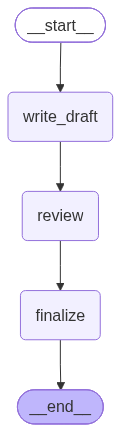

In [53]:
graph

In [54]:
config = {
    "configurable": {
        "thread_id": "oracle-review-01",
    }
}


In [57]:
initial_result = graph.invoke(
    {
        "request": "병원 예약 프로그램",
    },
    config,
)


In [58]:
print(initial_result['__interrupt__'][0].value['draft'])

안녕하세요. 시니어 아키텍트입니다. 요청하신 **[병원 예약 프로그램]**에 대한 기능 명세서를 작성하였습니다. 

본 설계는 환자의 편의성과 병원 행정 효율성을 극대화하는 데 초점을 맞추었으며, 확장성과 데이터 정합성을 고려하여 설계되었습니다.

---

# [기능 명세서] 병원 예약 관리 시스템 (Hospital Appointment System)

## 1. 기능 개요
본 시스템은 환자가 온라인으로 원하는 진료 과목과 의사를 선택해 예약하고, 병원 관리자가 이를 효율적으로 제어 및 관리하기 위한 플랫폼입니다. 실시간 예약 상태 반영을 통해 중복 예약을 방지하고, 알림 서비스를 통해 노쇼(No-show)를 최소화하는 것을 목적으로 합니다.

---

## 2. 사용자 시나리오
### 2.1 환자(Patient) 관점
1. **로그인 및 인증**: 환자가 계정으로 로그인하여 개인 정보를 확인합니다.
2. **진료 예약**: [진료 과목 선택] $\rightarrow$ [의사 선택] $\rightarrow$ [가능한 날짜 및 시간대 선택] $\rightarrow$ [증상 입력] $\rightarrow$ [예약 확정].
3. **예약 조회 및 변경**: '내 예약 내역'에서 현재 예약 상태를 확인하고, 필요 시 일정 변경 또는 취소를 요청합니다.
4. **알림 수신**: 예약 완료 및 진료 전 리마인드 알림(Push/SMS)을 받습니다.

### 2.2 병원 관리자(Admin/Staff) 관점
1. **스케줄 관리**: 일별/주별 의사별 예약 현황을 대시보드로 확인합니다.
2. **예약 승인 및 조정**: 환자의 예약 요청을 검토하여 확정하거나, 병원 사정에 따라 시간을 조정합니다.
3. **환자 정보 조회**: 예약된 환자의 기본 정보와 입력한 증상을 미리 확인하여 진료를 준비합니다.

---

## 3. 화면 설계 (와이어프레임 요소)

### 3.1 환자용 인터페이스
*   **메인 홈**: 검색바(과목/의사), 빠른 예약 버튼, 내 다음 예약 정보 요약.

In [59]:
final_result = graph.invoke(
    Command(
        resume={
            "approved": True,
            "feedback": "내용을 확인했습니다. 승인합니다. ",
        }
    ),
    config,
)


In [60]:
final_result

{'request': '병원 예약 프로그램',
 'draft_document': '안녕하세요. 시니어 아키텍트입니다. 요청하신 **[병원 예약 프로그램]**에 대한 기능 명세서를 작성하였습니다. \n\n본 설계는 환자의 편의성과 병원 행정 효율성을 극대화하는 데 초점을 맞추었으며, 확장성과 데이터 정합성을 고려하여 설계되었습니다.\n\n---\n\n# [기능 명세서] 병원 예약 관리 시스템 (Hospital Appointment System)\n\n## 1. 기능 개요\n본 시스템은 환자가 온라인으로 원하는 진료 과목과 의사를 선택해 예약하고, 병원 관리자가 이를 효율적으로 제어 및 관리하기 위한 플랫폼입니다. 실시간 예약 상태 반영을 통해 중복 예약을 방지하고, 알림 서비스를 통해 노쇼(No-show)를 최소화하는 것을 목적으로 합니다.\n\n---\n\n## 2. 사용자 시나리오\n### 2.1 환자(Patient) 관점\n1. **로그인 및 인증**: 환자가 계정으로 로그인하여 개인 정보를 확인합니다.\n2. **진료 예약**: [진료 과목 선택] $\\rightarrow$ [의사 선택] $\\rightarrow$ [가능한 날짜 및 시간대 선택] $\\rightarrow$ [증상 입력] $\\rightarrow$ [예약 확정].\n3. **예약 조회 및 변경**: \'내 예약 내역\'에서 현재 예약 상태를 확인하고, 필요 시 일정 변경 또는 취소를 요청합니다.\n4. **알림 수신**: 예약 완료 및 진료 전 리마인드 알림(Push/SMS)을 받습니다.\n\n### 2.2 병원 관리자(Admin/Staff) 관점\n1. **스케줄 관리**: 일별/주별 의사별 예약 현황을 대시보드로 확인합니다.\n2. **예약 승인 및 조정**: 환자의 예약 요청을 검토하여 확정하거나, 병원 사정에 따라 시간을 조정합니다.\n3. **환자 정보 조회**: 예약된 환자의 기본 정보와 입력한 증상을 미리 확인하여 진료를 준비합니다.\n\n---\n\n## 3. 화면 설계 (와

## 반복 횟수 체크

In [4]:
class DocumentState(TypedDict):
    request: str
    draft_document: str
    approved: bool
    feedback: str
    final: str
    retry_count: int

In [5]:
def router(state: DocumentState) -> str:
    if state['approved']:
        return "final"
    return "rewrite"

In [7]:
MAX_RETRY = 3

def router(state: DocumentState) -> str:
    if state['approved'] or state['retry_count'] > MAX_RETRY:
        return "final"
    return "rewrite"

In [8]:
def write_draft(state : DocumentState) -> dict:
    # 현재까지 draft를 작성한 횟수 
    re_cnt = state.get('retry_count', 0)

    if re_cnt == 0:
        persona = """ 
            당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
            아래 규칙에 따라서 기능 명세서를 작성하세요. 
        
            규칙 
             - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
             - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
             - 화면 설계(와이어프레임): UI/UX 요소 포함
             - 데이터 흐름: 입력값과 출력값 정의
             - API 및 연동 정보: 외부 서비스와의 연결 여부
             - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
        """
        prompt = ChatPromptTemplate(
            [
                ('system', persona),
                ('human', "{request}")
            ]
        )
        chain = prompt | llm | StrOutputParser()
        rt = chain.invoke({'request' : state['request']})
        return {'draft_document' : rt, 're_cnt' : re_cnt + 1}
    elif state.get("approved") == False:
        persona = """ 
            당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
            아래 규칙에 따라서 기능 명세서를 작성하세요. 
            사용자가 요구한 거절 사유를 반영해서 다시 작성할 것 
            규칙 
             - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
             - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
             - 화면 설계(와이어프레임): UI/UX 요소 포함
             - 데이터 흐름: 입력값과 출력값 정의
             - API 및 연동 정보: 외부 서비스와의 연결 여부
             - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
        """
        prompt = ChatPromptTemplate(
            [
                ('system', persona),
                ('human', "요청 사항 : {request}\n\n 이전 작성내용: {context} \n\n거절사유 : {feedback}")
            ]
        )
        chain = prompt | llm | StrOutputParser()
        rt = chain.invoke({'request' : state['request'], 'feedback' : state['feedback'],
                          'context' : state['draft_document']})
        return {'draft_document' : rt, 're_cnt' : re_cnt + 1}


In [9]:
def review_document(state: DocumentState) -> dict:
    """사람에게 문서 승인 여부를 요청한다."""

    decision = interrupt(
        {
            "action": "review_document",
            "message": "문서를 검토하고 승인 여부를 선택해 주세요.",
            "draft": state["draft_document"],
            "options": ["approve", "reject"],
        }
    )

    return {
        "approved": decision["approved"],
        "feedback": decision.get("feedback", ""),
    }


In [10]:
def finalize_document(state: DocumentState) -> dict:
    """승인 여부에 따라 최종 문서를 만든다."""

    if state["approved"]:
        status = "APPROVED"
    else:
        status = "REJECTED"

    return {
        "final": (
            f"{state['draft_document']}\n"
            f"[{status}] {state['feedback']}"
        ),
    }


In [11]:
builder = StateGraph(DocumentState)

builder.add_node("write_draft", write_draft)
builder.add_node("review", review_document)
builder.add_node("finalize", finalize_document)

builder.add_edge(START, "write_draft")
builder.add_edge("write_draft", "review")
builder.add_conditional_edges(
    "review",
    router,
    {
        "final" : "finalize",
        "rewrite" : "write_draft"
    }
)
# builder.add_edge("review", "finalize")
builder.add_edge("finalize", END)

checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer,
)


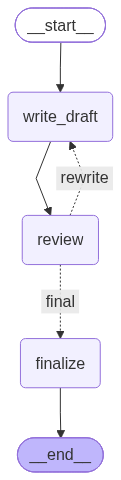

In [12]:
graph

In [13]:
config = {
    "configurable": {
        "thread_id": "oracle-review-02",
    }
}


initial_result = graph.invoke(
    {
        "request": "병원 예약 프로그램",
    },
    config,
)


In [14]:
print(initial_result['__interrupt__'][-1].value.get('draft'))

안녕하세요. 시니어 아키텍트입니다. 요청하신 **[병원 예약 프로그램]**에 대한 기능 명세서를 작성하였습니다. 

본 설계는 환자의 편의성과 병원 운영의 효율성을 극대화하는 데 초점을 맞추었으며, 확장성과 안정성을 고려한 구조로 설계되었습니다.

---

# [기능 명세서] 병원 예약 관리 시스템 (Hospital Appointment System)

## 1. 기능 개요
본 시스템은 환자가 온라인으로 원하는 진료 과목과 의사를 선택하여 예약하고, 병원 측에서는 이를 효율적으로 관리 및 확정하는 **통합 예약 플랫폼**입니다. 대기 시간을 단축하고 예약 누락을 방지하며, 데이터 기반의 진료 스케줄 관리를 목적으로 합니다.

---

## 2. 사용자 시나리오
### 2.1 환자(Patient) 시나리오
1. **로그인 및 인증**: 사용자는 계정을 생성하고 로그인합니다.
2. **진료 탐색**: 원하는 진료 과목(예: 내과, 정형외과)을 선택하거나 의사 이름을 검색합니다.
3. **일정 선택**: 해당 의사의 실시간 예약 가능 시간대(Slot)를 확인하고 원하는 시간을 선택합니다.
4. **예약 신청**: 방문 목적(증상)을 입력하고 예약을 요청합니다.
5. **확인 및 알림**: 예약 완료 후 알림톡/SMS를 통해 확정 메시지를 받습니다.
6. **관리**: '내 예약 내역'에서 예약 상태를 확인하거나 취소/변경합니다.

### 2.2 병원 관리자(Admin/Staff) 시나리오
1. **대시보드 확인**: 당일 및 주간 예약 현황을 캘린더 형태로 확인합니다.
2. **예약 승인/조정**: 환자의 요청을 검토하여 승인하거나, 부득이한 경우 시간을 조정하여 재요청합니다.
3. **환자 관리**: 예약된 환자의 기본 정보와 방문 목적을 미리 확인하여 진료를 준비합니다.
4. **스케줄 설정**: 의사별 휴진일 및 진료 가능 시간대를 설정합니다.

---

## 3. 화면 설계 (와이어프레임 요소)

### 3.1 메인 페이지 (Main Page)
- **상단*

In [18]:
result = graph.invoke(
    Command(
        resume={
            "approved": False,
            "feedback": "내용에 대한 전체 수정이 필요함. ",
        }
    ),
    config,
)


In [19]:
result

{'request': '병원 예약 프로그램',
 'draft_document': '안녕하세요. 시니어 아키텍트입니다. 요청하신 **[병원 예약 프로그램]**에 대한 기능 명세서를 작성하였습니다. \n\n본 설계는 환자의 편의성과 병원 운영의 효율성을 극대화하는 데 초점을 맞추었으며, 확장성과 안정성을 고려한 구조로 설계되었습니다.\n\n---\n\n# [기능 명세서] 병원 예약 관리 시스템 (Hospital Appointment System)\n\n## 1. 기능 개요\n본 시스템은 환자가 온라인으로 원하는 진료 과목과 의사를 선택하여 예약하고, 병원 측에서는 이를 효율적으로 관리 및 확정하는 **통합 예약 플랫폼**입니다. 대기 시간을 단축하고 예약 누락을 방지하며, 데이터 기반의 진료 스케줄 관리를 목적으로 합니다.\n\n---\n\n## 2. 사용자 시나리오\n### 2.1 환자(Patient) 시나리오\n1. **로그인 및 인증**: 사용자는 계정을 생성하고 로그인합니다.\n2. **진료 탐색**: 원하는 진료 과목(예: 내과, 정형외과)을 선택하거나 의사 이름을 검색합니다.\n3. **일정 선택**: 해당 의사의 실시간 예약 가능 시간대(Slot)를 확인하고 원하는 시간을 선택합니다.\n4. **예약 신청**: 방문 목적(증상)을 입력하고 예약을 요청합니다.\n5. **확인 및 알림**: 예약 완료 후 알림톡/SMS를 통해 확정 메시지를 받습니다.\n6. **관리**: \'내 예약 내역\'에서 예약 상태를 확인하거나 취소/변경합니다.\n\n### 2.2 병원 관리자(Admin/Staff) 시나리오\n1. **대시보드 확인**: 당일 및 주간 예약 현황을 캘린더 형태로 확인합니다.\n2. **예약 승인/조정**: 환자의 요청을 검토하여 승인하거나, 부득이한 경우 시간을 조정하여 재요청합니다.\n3. **환자 관리**: 예약된 환자의 기본 정보와 방문 목적을 미리 확인하여 진료를 준비합니다.\n4. **스케줄 설정**: 의사별 휴진일 및 진료 가능 시간대

In [ ]:
#['nocolor', 'linux', 'neutral', 'neutral:nt', 'neutral:posix', 'lightbg', 'pride', 'pride:l', 'gruvbox-dark']

In [17]:
%colors lightbg

In [20]:
MAX_RETRY = 3 
class DocumentState(TypedDict):
    request : str 
    draft_document  : str 
    approved : bool 
    feedback : str 
    final : str 
    retry_count : int 

def write_draft(state : DocumentState) -> dict:
    # 현재까지 draft를 작성한 횟수 
    retry_count = state.get('retry_count', 0)

    if retry_count == 0:
        persona = """ 
            당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
            아래 규칙에 따라서 기능 명세서를 작성하세요. 
        
            규칙 
             - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
             - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
             - 화면 설계(와이어프레임): UI/UX 요소 포함
             - 데이터 흐름: 입력값과 출력값 정의
             - API 및 연동 정보: 외부 서비스와의 연결 여부
             - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
        """
        prompt = ChatPromptTemplate(
            [
                ('system', persona),
                ('human', "{request}")
            ]
        )
        chain = prompt | llm | StrOutputParser()
        rt = chain.invoke({'request' : state['request']})
        return {'draft_document' : rt, 'retry_count' : retry_count + 1}
    elif state.get("approved") == False:
        persona = """ 
            당신은 기능 명세서를 작성하는 시니어 아키텍처입니다. 
            아래 규칙에 따라서 기능 명세서를 작성하세요. 
            사용자가 요구한 거절 사유를 반영해서 다시 작성할 것 
            규칙 
             - 기능 개요: 해당 기능이 어떤 역할을 하는지 설명
             - 사용자 시나리오: 사용자가 기능을 어떻게 이용하는지 예시
             - 화면 설계(와이어프레임): UI/UX 요소 포함
             - 데이터 흐름: 입력값과 출력값 정의
             - API 및 연동 정보: 외부 서비스와의 연결 여부
             - 예외 처리 및 에러 케이스: 예기치 않은 상황 대응 방법
        """
        prompt = ChatPromptTemplate(
            [
                ('system', persona),
                ('human', "요청 사항 : {request}\n\n 이전 작성내용: {context} \n\n거절사유 : {feedback}")
            ]
        )
        chain = prompt | llm | StrOutputParser()
        rt = chain.invoke({'request' : state['request'], 'feedback' : state['feedback'],
                          'context' : state['draft_document']})
        return {'draft_document' : rt, 'retry_count' : retry_count + 1}

def review_document(state: DocumentState) -> dict:
    """사람에게 문서 승인 여부를 요청한다."""

    decision = interrupt(
        {
            "action": "review_document",
            "message": "문서를 검토하고 승인 여부를 선택해 주세요.",
            "draft": state["draft_document"],
            "options": ["approve", "reject"],
        }
    )

    return {
        "approved": decision["approved"],
        "feedback": decision.get("feedback", ""),
    }


def finalize_document(state: DocumentState) -> dict:
    """승인 여부에 따라 최종 문서를 만든다."""

    if state["approved"]:
        status = "APPROVED"
    else:
        status = "REJECTED"

    return {
        "final": (
            f"{state['draft_document']}\n"
            f"[{status}] {state['feedback']}"
        ),
    }


def router(state: DocumentState) -> str:
    if state['approved'] == True:
        return "final"
        
    elif state['retry_count'] <= MAX_RETRY:
        return "rewrite"
    else:
        return 'final'


In [21]:
builder = StateGraph(DocumentState)

builder.add_node("write_draft", write_draft)
builder.add_node("review", review_document)
builder.add_node("finalize", finalize_document)

builder.add_edge(START, "write_draft")
builder.add_edge("write_draft", "review")
builder.add_conditional_edges(
    "review",
    router,
    {
        "final" : "finalize",
        "rewrite" : "write_draft"
    }
)
# builder.add_edge("review", "finalize")
builder.add_edge("finalize", END)

checkpointer = InMemorySaver()

graph = builder.compile(
    checkpointer=checkpointer,
)


In [22]:
config = {
    "configurable": {
        "thread_id": "oracle-review-03",
    }
}


In [23]:
initial_result = graph.invoke(
    {
        "request": "병원 예약 프로그램",
    },
    config,
)


In [24]:
print(initial_result['__interrupt__'][-1].value.get('draft'))


안녕하세요. 시니어 아키텍트입니다. 요청하신 **[병원 예약 프로그램]**에 대한 기능 명세서를 작성해 드리겠습니다. 

본 명세서는 환자가 편리하게 진료를 예약하고, 병원 측에서 효율적으로 일정을 관리하는 것을 목표로 하는 **'환자-병원 매칭 예약 시스템'**을 기준으로 설계되었습니다.

---

# 📋 기능 명세서: 병원 예약 관리 시스템 (Hospital Appointment System)

## 1. 기능 개요 (Functional Overview)
본 시스템은 환자가 병원의 진료 가능 시간을 실시간으로 확인하여 예약하고, 의료진은 환자의 예약 현황을 관리하며 진료 스케줄을 최적화하는 것을 목적으로 합니다.
- **핵심 가치**: 예약 대기 시간 감소, 전화 예약 업무 부하 경감, 노쇼(No-show) 방지.
- **주요 타겟**: 환자(사용자), 병원 리셉션(관리자), 의료진(의사).

---

## 2. 사용자 시나리오 (User Scenarios)

### 시나리오 A: 환자의 진료 예약
1. **접속 및 로그인**: 환자가 앱/웹에 접속하여 로그인한다.
2. **진료과/의사 선택**: 원하는 진료과(예: 내과, 정형외과)를 선택하고 담당 의사를 지정한다.
3. **날짜 및 시간 선택**: 캘린더에서 예약 가능한 날짜를 선택하고, 활성화된 시간 슬롯(Time Slot)을 클릭한다.
4. **정보 입력**: 방문 목적(증상)을 간단히 입력하고 예약 확정 버튼을 누른다.
5. **확인**: 예약 완료 메시지와 함께 알림톡/SMS를 수신한다.

### 시나리오 B: 병원 관리자의 일정 관리
1. **대시보드 확인**: 관리자가 오늘 방문 예정인 환자 리스트를 확인한다.
2. **스케줄 조정**: 특정 의사의 갑작스러운 휴진 발생 시, 해당 시간대의 예약 건을 확인하고 환자에게 변경 안내를 보낸다.
3. **진료 상태 변경**: 환자가 내원하면 '대기 중' $\rightarrow$ '진료 중' $\rightarrow$ '완료'로 상태를 업데이트한다.



In [25]:
result = graph.invoke(
    Command(
        resume={
            "approved": False,
            "feedback": "내용에 대한 전체 수정이 필요함. ",
        }
    ),
    config,
)


In [28]:
result['__interrupt__'][-1].value

KeyError: '__interrupt__'

In [27]:
result = graph.invoke(
    Command(
        resume={
            "approved": True,
            "feedback": "이제 된거 같아.",
        }
    ),
    config,
)


In [29]:
result

{'request': '병원 예약 프로그램',
 'draft_document': '안녕하세요, 시니어 아키텍트입니다. \n\n이전의 명세서가 일반적인 \'매칭 플랫폼\' 형태의 가벼운 설계였다면, 이번에는 **실제 의료 현장에서 사용되는 [병원 통합 예약 및 환자 관리 시스템(Hospital Integrated Appointment & Patient Management System)]**의 관점에서 완전히 다시 설계하였습니다. \n\n단순한 예약 기능을 넘어, **접수-대기-진료-수납**으로 이어지는 병원 워크플로우(Workflow)를 반영하여 실무 중심의 기능 명세서를 작성하였습니다.\n\n---\n\n# 📋 기능 명세서: 병원 통합 예약 및 환자 관리 시스템\n\n## 1. 기능 개요 (Functional Overview)\n본 시스템은 환자의 예약 편의성을 높이는 동시에, 병원 내부의 **OCS(처방전달시스템) 및 EMR(전자의무기록)**과 연동 가능한 구조로 설계된 통합 관리 솔루션입니다. \n- **핵심 목적**: 환자 유입 경로의 디지털화, 원내 대기 시간의 효율적 분산, 의료진의 진료 스케줄 최적화.\n- **주요 기능**: 지능형 예약 슬롯 관리, 실시간 대기열 관제, 환자 방문 이력 기반의 맞춤형 예약, 자동 알림 시스템.\n- **사용자 역할**: \n    - **환자**: 예약 신청, 변경, 내원 알림 수신.\n    - **리셉션(원무과)**: 예약 승인/조정, 환자 접수 및 수납 관리.\n    - **의료진(의사/간호사)**: 진료 대기 명단 확인, 진료 상태 업데이트.\n\n---\n\n## 2. 사용자 시나리오 (User Scenarios)\n\n### 시나리오 A: 환자의 증상 기반 맞춤 예약\n1. **증상 선택**: 환자가 앱에 접속하여 \'증상(예: 고혈압, 갑상선 질환)\'을 선택한다.\n2. **전문의 추천**: 시스템이 해당 증상에 적합한 진료과와 전문의를 추천한다.\n3. **슬롯 선택**: 의사의 실시간 진료 가능

## 도구 사용

In [46]:
import os
import requests
from dotenv import load_dotenv
import urllib.request
import urllib.parse
from langchain_core.output_parsers import PydanticOutputParser

load_dotenv()

True

In [34]:
client_id = os.getenv('client_id')
client_secret = os.getenv('client_secret')

In [67]:
LOCAL_API_URL = "https://openapi.naver.com/v1/search/local.json"
BLOG_API_URL = "https://openapi.naver.com/v1/search/blog.json"

In [36]:
headers = {
    "X-Naver-Client-Id": client_id,
    "X-Naver-Client-Secret": client_secret
}


In [38]:
params = {'query' : "여의도 맛집", 'display' : 100, 'start': 1, "sort" : "sim"}
response = requests.get(LOCAL_API_URL, headers=headers, params=params)


In [40]:
response

<Response [200]>

1. 사용자 질의 -> 키워드 추출
2. 

In [41]:
from langchain_core.tools import tool
from pydantic import Field, BaseModel

In [42]:
class State(BaseModel):
    inputs: str = Field(description='사용자의 질문')

In [ ]:
class KeywordState(BaseModel):
    keyword: list[str] = Field(description=f"사용자의 입력에 대한 키워드")

@tool
def extract_keyword(state: KeywordState, inputs: str):
    state['inputs'] = inputs

    

In [53]:
# 사용자 질의 -> 키워드 추출 
class KeywordExtract(BaseModel):
    keywords : list[str] = Field(description="질의에서 네이버 검색에서 사용될 음식의 종류 키워드 추출 할 것", examples=['매운 짬뽕', '마라탕', '매운 떡볶이'])
    location : str = Field(description="사용자 질의에서 대표 지역을 추출할 것", default='', examples='대방역')


In [54]:
parser = PydanticOutputParser(pydantic_object=KeywordExtract)

In [59]:
prompt_text = """ 
    질의에서 네이버 지역 검색을 통하여 음식을 검색할려고 한다. 
    당신은 질의에서 검색어를 추출해야 한다. 

    예)   저녁에 대방역에서 아주 매운 음식을 먹고 싶어 
          추출 키워드   
          keywords : ['매운 짬뽕', '마라탕', '매운 떡볶이']
          location : '대방역'
    \n\n
    {format_instructions}

    질의 : {text}
"""


In [60]:
prompt = PromptTemplate(
        template=prompt_text,
        input_variables=["text"],
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )


In [61]:
chain = prompt | llm | parser

In [63]:
response = chain.invoke("저녁에 여의도에서 시원한 음식을 먹고 싶어")

In [64]:
total = []
for l, k in zip([response.location] * len(response.keywords), response.keywords):
    print(f"{l} {k}")
    params = {'query' : f"{l} {k}", 'display' : 5, 'start': 1, "sort" : "sim"}
    r = requests.get(LOCAL_API_URL, headers=headers, params=params)
    total.extend(r.json()['items'])


여의도 냉면
여의도 소바
여의도 물회
여의도 콩국수


In [65]:
total

[{'title': '정인면옥 본점',
  'link': '',
  'category': '한식>냉면',
  'description': '',
  'telephone': '',
  'address': '서울특별시 영등포구 여의도동 13-1 기독교침례회총회빌딩 1층',
  'roadAddress': '서울특별시 영등포구 국회대로76길 10 기독교침례회총회빌딩 1층',
  'mapx': '1269217518',
  'mapy': '375306331'},
 {'title': '일호면옥',
  'link': '',
  'category': '한식>냉면',
  'description': '',
  'telephone': '',
  'address': '서울특별시 영등포구 여의도동 36 롯데캐슬엠파이어 상가1층 110호',
  'roadAddress': '서울특별시 영등포구 의사당대로 127 롯데캐슬엠파이어 상가1층 110호',
  'mapx': '1269267102',
  'mapy': '375202488'},
 {'title': '피양옥 <b>여의도</b>점',
  'link': '',
  'category': '한식>냉면',
  'description': '',
  'telephone': '',
  'address': '서울특별시 영등포구 여의도동 43 1층',
  'roadAddress': '서울특별시 영등포구 국제금융로 70 1층',
  'mapx': '1269306464',
  'mapy': '375217315'},
 {'title': '평양관',
  'link': '',
  'category': '한식>냉면',
  'description': '',
  'telephone': '',
  'address': '서울특별시 영등포구 여의도동 53-11 상아빌딩지하 1층',
  'roadAddress': '서울특별시 영등포구 국제금융로 112 상아빌딩지하 1층',
  'mapx': '1269339149',
  'mapy': '375184075'},
 {'title':

In [68]:
total_blog = []
for l, k in zip([response.location] * len(response.keywords), response.keywords):
    print(f"{l} {k}")
    params = {'query' : f"{l} {k}", 'display' : 100, 'start': 1, "sort" : "sim"}
    r = requests.get(BLOG_API_URL, headers=headers, params=params)
    total_blog.extend(r.json()['items'])


여의도 냉면
여의도 소바
여의도 물회
여의도 콩국수


In [69]:
def search_local(keywords: str):
    """ 
    네이버 지역 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 5, 'start': 1, "sort" : "sim"}
    r = requests.get(LOCAL_API_URL, headers=headers, params=params)
    return r.json()['items']


In [73]:
def search_blog(keywords: str):
    """ 
    네이버 블로그 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 100, 'start': 1, "sort" : "sim"}
    r = requests.get(BLOG_API_URL, headers=headers, params=params)
    return [f"{x.get('title')} {x.get('description')}" for x in r.json()['items']]


토큰 사용량을 위해 불필요한 것들 제거

In [72]:
import re
re.sub(r"<[^>]+>", "", search_blog('여의도 소바')[0])

'찌는 무더위 시원한 잣 소바 삼동소바 :) 여의도 소바 맛집 #여의도 돈까스,#여의도 소바,#삼동소바 #여의도맛집 #소바맛집 #생활의달인소바 #소바맛집 #냉우동 #여의도우동 #여의도우동맛집 #여의도소바맛집 #삼동소바여의도점 #삼동소바메뉴'

In [74]:
def search_blog(keywords: str):
    """ 
    네이버 블로그 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 100, 'start': 1, "sort" : "sim"}
    r = requests.get(BLOG_API_URL, headers=headers, params=params)
    return re.sub(r"<[^>]+>", ""," ".join([f"{x.get('title')} {x.get('description')}" for x in r.json()['items']]))


In [80]:
print(search_blog('여의도 소바')[:1000])

찌는 무더위 시원한 잣 소바 삼동소바 :) 여의도 소바 맛집 #여의도 돈까스,#여의도 소바,#삼동소바 #여의도맛집 #소바맛집 #생활의달인소바 #소바맛집 #냉우동 #여의도우동 #여의도우동맛집 #여의도소바맛집 #삼동소바여의도점 #삼동소바메뉴 여의도 일식당 소바가 맛있는 마츠노하나 여의도 소바 메뉴가 특히 궁금했는데, 바질소바는 독특한 조합이라 한번 시도해보고 싶었고... 여의도 일식당 바질소바는 정말 신선한 조합이었습니다. 처음에는 바질과 소바가 어떻게 어울릴지 의구심이...  여의도 소바 맛집 소몽 더현대 근처 점심 추천 솔직 후기 메뉴 여의도 소바 맛집 소몽 메뉴입니다 기본 냉소바부터 우니, 새우장, 낫토 소바 이렇게 준비되어... 개인적으로 소바엔 가라아게가 잘 어울린다고 생각해서 같이 꼭 주문하시면 좋을 것 같아요 여의도 더현대...  여의도 맛집 소몽 후기 신선한 해산물 소바 덮밥이 매력적인 곳 잘 먹을 만큼 부담 없는 맛이었다 전체적으로 음식의 퀄리티가 높고 메뉴 구성도 다양해 여러 가지를 함께 주문해 나누어 먹기 좋은 곳 여의도에서 소바, 덮밥을 찾는다면 충분히 추천할 만한 식당이다 끗. 여의도 점심 추천 삼동소바 소바 맛집 인정 후기 - 주차가능...  전체적인 만족도가 높았던 방문이었습니다 #삼동소바여의도점 #여의도삼동소바 #여의도냉모밀 #여의도소바 #서울메밀소바맛집 #여의도밥집 #여의도소바맛집 #여의도소바우동 #여의도점심식사 #여의도맛집 여의도 점심 맛집 삼동소바 순두부짬뽕우동 정식 내돈내산...  조만간 또 소바 생각날 때 재방문할 예정이에요. #여의도점심맛집 #여의도맛집 #삼동소바여의도점 #여의도삼동소바 #여의도소바맛집 #여의도우동맛집 #순두부짬뽕우동 #여의도내돈내산 여의도 | 소몽 여의도 - 우니 냉소바, 고등어 들기름 소바...  소몽여의도주차 #소몽여의도캐치테이블 #소몽여의도예약 #소몽예약 #소몽웨이팅 #소몽여의도유부초밥 #여의도소몽소바 #여의도소바 #여의도점심 #여의도소몽예약 #여의도소몽웨이팅 #여의도소몽주차 여의도 소바 맛집 삼동소바

In [81]:
#데코레이터로 도구 만들기 

from langchain_core.tools import tool

@tool
def search_local(keywords: str):
    """
    네이버 지역 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 5, 'start': 1, "sort" : "sim"}
    r = requests.get(LOCAL_API_URL, headers=headers, params=params)
    return r.json()['items']

@tool
def search_blog(keywords: str):
    """ 
    네이버 블로그 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 100, 'start': 1, "sort" : "sim"}
    r = requests.get(BLOG_API_URL, headers=headers, params=params)
    return re.sub(r"<[^>]+>", "","\n\n".join([f"{x.get('title')} {x.get('description')}" for x in r.json()['items']]))


In [82]:
tools = [
    search_local,
    search_blog
]

In [83]:
llm_tools = llm.bind_tools(tools)

In [86]:
tools_result = llm_tools.invoke("여의도 콩국수 맛집 알려줘")

In [87]:
tools_result

AIMessage(content='', additional_kwargs={'reasoning_content': '*   User wants recommendations for "Kong-guksu" (soy milk noodle soup) restaurants in "Yeouido".\n    *   Goal: Provide a list of highly-rated or popular spots.\n\n    *   `search_local`: Good for finding specific restaurants, their locations, and basic ratings/info.\n    *   `search_blog`: Good for finding detailed reviews, "hidden gems," and current trends.\n\n    *   Step 1: Use `search_local` to get a list of restaurants specializing in Kong-guksu or known for it in Yeouido.\n    *   Step 2: Use `search_blog` to find real user reviews and recommendations to filter the best ones.\n\n    *   `search_local(keywords="여의도 콩국수 맛집")`\n    *   `search_blog(keywords="여의도 콩국수 맛집 추천")`'}, response_metadata={'model': 'gemma4:31b-cloud', 'created_at': '2026-08-03T07:08:49.527114544Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1627673040, 'load_duration': None, 'prompt_eval_count': 164, 'prompt_eval_duration': None, 'eva

In [92]:
from typing import TypedDict
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os
import urllib.request
import urllib.parse
import requests 
from langchain_core.tools import tool
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from langchain_core.messages import HumanMessage
import re 



In [93]:
load_dotenv()

api_key = os.getenv("OLLAMA_API_KEY")
headers = {
   "Authorization": f"Bearer {api_key}"
}


In [94]:
llm = ChatOllama(
   base_url="https://ollama.com", # 원격 서버 주소
   model="gemma4:31b-cloud",
   client_kwargs={"headers": headers},
   temperature=0.2,
   reasoning=True
)

In [96]:
LOCAL_API_URL = "https://openapi.naver.com/v1/search/local.json"
BLOG_API_URL = "https://openapi.naver.com/v1/search/blog.json"
client_id=os.getenv('client_id')
client_secret=os.getenv('client_secret')
headers = {
    "X-Naver-Client-Id": client_id,
    "X-Naver-Client-Secret": client_secret
}

In [97]:
@tool
def search_local(keywords: str):
    """
    네이버 지역 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 5, 'start': 1, "sort" : "sim"}
    r = requests.get(LOCAL_API_URL, headers=headers, params=params)
    return r.json()['items']

@tool
def search_blog(keywords: str):
    """ 
    네이버 블로그 검색 API를 활용하여 사용자 검색한 내용을 리턴 함 
    keywords : 여의도 냉명 
    return : 검색 결과 list 
    """
    params = {'query' : keywords, 'display' : 100, 'start': 1, "sort" : "sim"}
    r = requests.get(BLOG_API_URL, headers=headers, params=params)
    return re.sub(r"<[^>]+>", "","\n\n".join([f"{x.get('title')} {x.get('description')}" for x in r.json()['items']]))
tools = [
    search_local,
    search_blog,
]


In [98]:
llm_tools = llm.bind_tools(tools)

In [99]:
class recommendState(TypedDict):
    query  : str 
    keywords : list 
    location : str
    messages: list
    report : str 

# 사용자 질의 -> 키워드 추출 
class KeywordExtract(BaseModel):
    keywords : list[str] = Field(description="질의에서 네이버 검색에서 사용될 음식의 종류 키워드 추출 할 것")
    location : str = Field(description="사용자 질의에서 대표 지역을 추출할 것", default='')

In [100]:
def extract_node(state : recommendState) -> dict : 
    parser = PydanticOutputParser(pydantic_object=KeywordExtract)

    prompt_text = """ 
        질의에서 네이버 지역 검색을 통하여 음식을 검색할려고 한다. 
        당신은 질의에서 검색어를 추출해야 한다. 
    
        예)   저녁에 대방역에서 아주 매운 음식을 먹고 싶어 
              추출 키워드   
              keywords : ['매운 짬뽕', '마라탕', '매운 떡볶이']
              location : '대방역'
        \n\n
        {format_instructions}
    
        질의 : {text}
    """
    prompt = PromptTemplate(
            template=prompt_text,
            input_variables=["text"],
            partial_variables={"format_instructions": parser.get_format_instructions()},
        )
    chain = prompt | llm | parser
    result = chain.invoke(state['query'])
    return {'keywords' : result.keywords, 'location' : result.location}

In [101]:
def search_agent(state: recommendState):

    question = f"""
                지역 : {state['location']}
                음식 : {', '.join(state['keywords'])}
                
                맛집을 추천해줘.
                필요하면 search_local 과 search_blog를 사용해.
                """

    response = llm_tools.invoke(
        state.get("messages", [])
        + [HumanMessage(content=question)]
    )

    return {
        "messages": state.get("messages", [])
        + [response]
    }

In [102]:
def generate_report(state: recommendState):

    prompt = f"""
다음 검색 결과를 이용하여
맛집 추천 보고서를 작성하라.

{state['messages']}
"""

    result = llm.invoke(prompt)

    return {
        "report": result.content
    }

In [103]:
tools = [
    search_local,
    search_blog,
]
tool_node = ToolNode(tools)
llm_tools = llm.bind_tools(tools)

In [104]:
from langgraph.prebuilt import tools_condition

builder = StateGraph(recommendState)

builder.add_node("extract", extract_node)
builder.add_node("search", search_agent)
builder.add_node("report", generate_report)
builder.add_node("tools", tool_node)

builder.add_edge(START, "extract")
builder.add_edge("extract", "search")
builder.add_conditional_edges(
    "search",
    tools_condition,
    {
        "tools" : "tools",
        "__end__" : "report"
    }
)
builder.add_edge("tools", "search")
builder.add_edge("report", END)

graph  = builder.compile()

In [ ]:
result = graph.invoke(
    {
        "query": "여의도에서 콩국수 맛집 추천해줘",
        "messages": []
    }
)
